# Figure S01 final source rebuild

Run top-to-bottom. This notebook rebuilds the three computational panels for Figure S1 from the before/after compensation H5AD files.

Panels A–C show mean slide-level clustering scores before and after compensation for Silhouette, Davies–Bouldin, and Calinski–Harabasz metrics. All three metrics are calculated together once for each shared slide and reused across the three plots.

## 1. Configure source inputs and analysis settings

The segmentation H5AD files are paired before and after compensation. Clustering metrics are calculated independently within each shared slide using Leiden labels in PCA space.

In [1]:
# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)


In [2]:
# ============================================================
# FILE LOCATIONS
# ============================================================

BASE_DIR = Path(
    "/mnt/jwh83-data/Confetti/output/Redsea/Clustering"
)

FILES = {
    "Mesmer": {
        "before": "mesmer_beforeREDSEA_leiden.h5ad",
        "after": "mesmer_afterREDSEA_leiden.h5ad",
    },
    "Cellpose Cyto3": {
        "before": "cellpose_cyto3_beforeREDSEA_leiden.h5ad",
        "after": "cellpose_cyto3_afterREDSEA_leiden.h5ad",
    },
    "CellposeSAM": {
        "before": "cellposeSAM_beforeREDSEA_leiden.h5ad",
        "after": "cellposeSAM_afterREDSEA_leiden.h5ad",
    },
    "CellSAM": {
        "before": "cellSAM_beforeREDSEA_leiden.h5ad",
        "after": "cellSAM_afterREDSEA_leiden.h5ad",
    },
    "InstanSeg": {
        "before": "instanseg_beforeREDSEA_leiden.h5ad",
        "after": "instanseg_afterREDSEA_leiden.h5ad",
    },
    "MicroSAM": {
        "before": "microSAM_beforeREDSEA_leiden.h5ad",
        "after": "microSAM_afterREDSEA_leiden.h5ad",
    },
}

ALGORITHM_ORDER = list(FILES.keys())


In [3]:
# ============================================================
# ANALYSIS SETTINGS
# ============================================================

REGION_COL = "slide_name"
GROUPBY = "leiden"
USE_REP = "X_pca"

METRIC_LABELS = {
    "silhouette": "Silhouette score",
    "davies_bouldin": "Davies–Bouldin score",
    "calinski_harabasz": "Calinski–Harabasz score",
}


In [4]:
# ============================================================
# COLORS
# ============================================================

COLOR_BEFORE = "#888780"
COLOR_AFTER = "#378ADD"
DOT_COLOR = "#222222"
LINE_COLOR = "#C7C4B8"


## 2. Calculate slide-level clustering metrics

Each method is loaded once for the before and after conditions. Only slides present in both conditions are scored. Silhouette, Davies–Bouldin, and Calinski–Harabasz scores are calculated together so the H5AD data do not need to be reprocessed separately for each panel.

In [5]:
# ============================================================
# DATA LOADING
# ============================================================

def read_cluster_file(filename):
    filepath = BASE_DIR / filename

    if not filepath.exists():
        raise FileNotFoundError(
            f"File not found: {filepath}"
        )

    return sc.read_h5ad(filepath)


In [6]:
# ============================================================
# CLUSTERING METRIC CALCULATION
# ============================================================

def compute_cluster_metrics(adata, label):
    results = {
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
    }

    if USE_REP not in adata.obsm:
        print(f"[{label}] skipped: {USE_REP} not found")
        return results

    if GROUPBY not in adata.obs:
        print(f"[{label}] skipped: {GROUPBY} not found")
        return results

    X = np.asarray(
        adata.obsm[USE_REP],
        dtype=np.float32,
    )

    labels = (
        adata.obs[GROUPBY]
        .astype(str)
        .to_numpy()
    )

    valid = np.isfinite(X).all(axis=1)
    X = X[valid]
    labels = labels[valid]

    n_cells = X.shape[0]
    n_clusters = np.unique(labels).size

    if (
        n_cells < 3
        or n_clusters < 2
        or n_clusters >= n_cells
    ):
        print(
            f"[{label}] skipped: "
            f"{n_cells:,} cells and {n_clusters} clusters"
        )
        return results

    try:
        import cupy as cp
        import cuml.metrics as cuml_metrics

        results["silhouette"] = float(
            cuml_metrics.silhouette_score(
                cp.asarray(X),
                labels,
            )
        )

    except Exception:
        results["silhouette"] = float(
            silhouette_score(
                X,
                labels,
            )
        )

    results["davies_bouldin"] = float(
        davies_bouldin_score(
            X,
            labels,
        )
    )

    results["calinski_harabasz"] = float(
        calinski_harabasz_score(
            X,
            labels,
        )
    )

    print(
        f"[{label}] "
        f"{n_cells:,} cells | "
        f"{n_clusters} clusters | "
        f"Silhouette: {results['silhouette']:.4f} | "
        f"DB: {results['davies_bouldin']:.4f} | "
        f"CH: {results['calinski_harabasz']:.4f}"
    )

    return results


In [7]:
# ============================================================
# CALCULATE ALL THREE METRICS ONCE PER SHARED SLIDE
# ============================================================

def compute_all_slide_clustering_metrics():
    result_rows = []

    for method, filenames in FILES.items():
        print()
        print("=" * 70)
        print(f"Scoring {method}")
        print("=" * 70)

        adata_before = read_cluster_file(
            filenames["before"]
        )

        adata_after = read_cluster_file(
            filenames["after"]
        )

        if REGION_COL not in adata_before.obs:
            raise KeyError(
                f"{REGION_COL!r} was not found in "
                f"{filenames['before']}"
            )

        if REGION_COL not in adata_after.obs:
            raise KeyError(
                f"{REGION_COL!r} was not found in "
                f"{filenames['after']}"
            )

        before_regions = set(
            adata_before.obs[REGION_COL].astype(str)
        )

        after_regions = set(
            adata_after.obs[REGION_COL].astype(str)
        )

        shared_regions = sorted(
            before_regions & after_regions
        )

        only_before = sorted(
            before_regions - after_regions
        )

        only_after = sorted(
            after_regions - before_regions
        )

        if only_before:
            print(
                "Slides found only before Compensation:",
                only_before,
            )

        if only_after:
            print(
                "Slides found only after Compensation:",
                only_after,
            )

        print(f"Shared slides: {len(shared_regions)}")

        for region in shared_regions:
            before_mask = (
                adata_before.obs[REGION_COL].astype(str)
                == region
            )

            after_mask = (
                adata_after.obs[REGION_COL].astype(str)
                == region
            )

            sub_before = adata_before[before_mask].copy()
            sub_after = adata_after[after_mask].copy()

            before_metrics = compute_cluster_metrics(
                sub_before,
                f"{method} | {region} | before Compensation",
            )

            after_metrics = compute_cluster_metrics(
                sub_after,
                f"{method} | {region} | after Compensation",
            )

            result_rows.append(
                {
                    "method": method,
                    "region": region,
                    "timepoint": "before",
                    "n_cells": sub_before.n_obs,
                    **before_metrics,
                }
            )

            result_rows.append(
                {
                    "method": method,
                    "region": region,
                    "timepoint": "after",
                    "n_cells": sub_after.n_obs,
                    **after_metrics,
                }
            )

            del sub_before
            del sub_after

        del adata_before
        del adata_after

    return pd.DataFrame(result_rows)


In [8]:
# ============================================================
# RUN ALL CALCULATIONS ONCE
# ============================================================

slide_clustering_results = (
    compute_all_slide_clustering_metrics()
)



Scoring Mesmer


/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Shared slides: 8
[Mesmer | B004-A-004 | before Compensation] 15,012 cells | 34 clusters | Silhouette: 0.0345 | DB: 1.9876 | CH: 527.5605
[Mesmer | B004-A-004 | after Compensation] 14,925 cells | 33 clusters | Silhouette: 0.0054 | DB: 2.0977 | CH: 492.5317
[Mesmer | B004-A-008 | before Compensation] 21,347 cells | 38 clusters | Silhouette: 0.0052 | DB: 2.0779 | CH: 626.4781
[Mesmer | B004-A-008 | after Compensation] 21,308 cells | 35 clusters | Silhouette: 0.0025 | DB: 2.2841 | CH: 689.0974
[Mesmer | B004-A-104 | before Compensation] 25,037 cells | 35 clusters | Silhouette: -0.0004 | DB: 1.9632 | CH: 796.3580
[Mesmer | B004-A-104 | after Compensation] 24,907 cells | 34 clusters | Silhouette: -0.0209 | DB: 2.2433 | CH: 633.3563
[Mesmer | B004-A-204 | before Compensation] 13,459 cells | 35 clusters | Silhouette: 0.0065 | DB: 1.9530 | CH: 428.5557
[Mesmer | B004-A-204 | after Compensation] 13,413 cells | 35 clusters | Silhouette: -0.0261 | DB: 2.1896 | CH: 413.1370
[Mesmer | B004-A-304 | b

/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Shared slides: 8
[Cellpose Cyto3 | B004-A-004 | before Compensation] 10,065 cells | 31 clusters | Silhouette: 0.0449 | DB: 1.7990 | CH: 400.9104
[Cellpose Cyto3 | B004-A-004 | after Compensation] 9,967 cells | 29 clusters | Silhouette: 0.0176 | DB: 2.0018 | CH: 349.1089
[Cellpose Cyto3 | B004-A-008 | before Compensation] 20,455 cells | 34 clusters | Silhouette: -0.0098 | DB: 1.9725 | CH: 629.4095
[Cellpose Cyto3 | B004-A-008 | after Compensation] 20,400 cells | 30 clusters | Silhouette: 0.0118 | DB: 2.2673 | CH: 696.9800
[Cellpose Cyto3 | B004-A-104 | before Compensation] 23,479 cells | 31 clusters | Silhouette: -0.0007 | DB: 1.9689 | CH: 839.2152
[Cellpose Cyto3 | B004-A-104 | after Compensation] 23,345 cells | 30 clusters | Silhouette: -0.0323 | DB: 2.1166 | CH: 628.4748
[Cellpose Cyto3 | B004-A-204 | before Compensation] 12,656 cells | 32 clusters | Silhouette: -0.0473 | DB: 2.0904 | CH: 407.0554
[Cellpose Cyto3 | B004-A-204 | after Compensation] 12,570 cells | 29 clusters | Silhoue

...

Shared slides: 8
[CellSAM | B004-A-004 | before Compensation] 16,144 cells | 34 clusters | Silhouette: 0.0125 | DB: 2.0179 | CH: 509.3135
[CellSAM | B004-A-004 | after Compensation] 16,087 cells | 44 clusters | Silhouette: -0.0322 | DB: 2.2186 | CH: 413.5603
[CellSAM | B004-A-008 | before Compensation] 25,903 cells | 39 clusters | Silhouette: -0.0041 | DB: 1.9779 | CH: 791.8408
[CellSAM | B004-A-008 | after Compensation] 25,829 cells | 50 clusters | Silhouette: -0.0411 | DB: 2.1607 | CH: 631.4462
[CellSAM | B004-A-104 | before Compensation] 30,796 cells | 35 clusters | Silhouette: 0.0027 | DB: 1.9035 | CH: 936.0467
[CellSAM | B004-A-104 | after Compensation] 30,666 cells | 47 clusters | Silhouette: -0.0285 | DB: 2.1593 | CH: 666.6408
[CellSAM | B004-A-204 | before Compensation] 17,270 cells | 36 clusters | Silhouette: -0.0325 | DB: 2.0803 | CH: 543.9996
[CellSAM | B004-A-204 | after Compensation] 17,200 cells | 49 clusters | Silhouette: -0.0802 | DB: 2.4325 | CH: 410.3542
[CellSAM | B0

/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Shared slides: 8
[InstanSeg | B004-A-004 | before Compensation] 14,625 cells | 34 clusters | Silhouette: 0.0063 | DB: 1.8461 | CH: 425.5404
[InstanSeg | B004-A-004 | after Compensation] 14,455 cells | 34 clusters | Silhouette: -0.0202 | DB: 1.8383 | CH: 393.6562
[InstanSeg | B004-A-008 | before Compensation] 26,862 cells | 39 clusters | Silhouette: -0.0084 | DB: 2.0619 | CH: 783.2499
[InstanSeg | B004-A-008 | after Compensation] 26,599 cells | 36 clusters | Silhouette: -0.0367 | DB: 2.1251 | CH: 663.9483
[InstanSeg | B004-A-104 | before Compensation] 33,030 cells | 37 clusters | Silhouette: -0.0771 | DB: 1.8415 | CH: 812.4349
[InstanSeg | B004-A-104 | after Compensation] 32,497 cells | 34 clusters | Silhouette: -0.0391 | DB: 2.1729 | CH: 712.5651
[InstanSeg | B004-A-204 | before Compensation] 17,183 cells | 36 clusters | Silhouette: -0.0461 | DB: 2.2408 | CH: 527.4535
[InstanSeg | B004-A-204 | after Compensation] 17,110 cells | 34 clusters | Silhouette: -0.0727 | DB: 2.1916 | CH: 516.5

/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Shared slides: 8
[MicroSAM | B004-A-004 | before Compensation] 10,645 cells | 32 clusters | Silhouette: 0.0233 | DB: 1.9373 | CH: 362.5008
[MicroSAM | B004-A-004 | after Compensation] 10,648 cells | 36 clusters | Silhouette: -0.0218 | DB: 2.2569 | CH: 294.3398
[MicroSAM | B004-A-008 | before Compensation] 27,199 cells | 35 clusters | Silhouette: -0.0135 | DB: 2.1766 | CH: 803.4854
[MicroSAM | B004-A-008 | after Compensation] 27,147 cells | 37 clusters | Silhouette: -0.0314 | DB: 2.1372 | CH: 712.2462
[MicroSAM | B004-A-104 | before Compensation] 30,485 cells | 33 clusters | Silhouette: 0.0050 | DB: 2.0596 | CH: 953.5709
[MicroSAM | B004-A-104 | after Compensation] 30,510 cells | 36 clusters | Silhouette: -0.0592 | DB: 2.1061 | CH: 760.9984
[MicroSAM | B004-A-204 | before Compensation] 18,388 cells | 35 clusters | Silhouette: -0.0663 | DB: 2.0348 | CH: 589.9646
[MicroSAM | B004-A-204 | after Compensation] 18,424 cells | 37 clusters | Silhouette: -0.0658 | DB: 2.2202 | CH: 467.4567
[Micr

## 3. Plot settings

Edit figure dimensions, font sizes, bar widths, marker sizes, and line appearance here. Rerun this cell and the plotting cells after making visual changes; the clustering metrics do not need to be recalculated.

In [9]:
# ============================================================
# PLOT SETTINGS
#
# EDIT ALL FONT SIZES IN THIS SECTION.
# Rerun this cell and the plotting cells after making changes.
# ============================================================

PLOT_SETTINGS = {
    # General font
    "font_family": "DejaVu Sans",

    # ========================================================
    # EDIT ALL FONT SIZES HERE
    # ========================================================
    "title_fontsize": 15,
    "axis_label_fontsize": 13,
    "x_tick_fontsize": 13,
    "y_tick_fontsize": 13,
    "legend_fontsize": 13,

    # Figure dimensions
    "figure_size": (11, 5.5),

    # Spacing
    "title_pad": 12,

    # Bar and line appearance
    "bar_width": 0.35,
    "zero_linewidth": 0.80,
    "connecting_linewidth": 0.80,

    # Marker appearance
    "slide_dot_size": 22,
    "slide_dot_alpha": 0.85,
    "connecting_line_alpha": 0.80,
}

plt.rcParams.update(
    {
        "font.family": PLOT_SETTINGS["font_family"],
        "axes.titlesize": PLOT_SETTINGS["title_fontsize"],
        "axes.labelsize": PLOT_SETTINGS["axis_label_fontsize"],
        "xtick.labelsize": PLOT_SETTINGS["x_tick_fontsize"],
        "ytick.labelsize": PLOT_SETTINGS["y_tick_fontsize"],
        "legend.fontsize": PLOT_SETTINGS["legend_fontsize"],
    }
)


## 4. Shared plotting function

For each metric, the bars show the arithmetic mean of the valid slide-level scores. Black dots show individual slide-level scores, and lines connect paired before/after values for the same slide.

In [10]:
# ============================================================
# MEAN SLIDE-LEVEL BEFORE/AFTER BAR PLOT
#
# Bars:
#   Arithmetic mean of slide-level scores.
#
# Dots:
#   Individual slide-level scores.
#
# Lines:
#   Paired before/after scores for the same slide.
# ============================================================

def plot_method_before_after(
    slide_results,
    metric,
):
    df = slide_results.loc[
        slide_results["timepoint"].isin(
            ["before", "after"]
        )
    ].copy()

    df["region"] = df["region"].astype(str)

    summary_df = (
        df.groupby(
            ["method", "timepoint"],
            observed=True,
        )[metric]
        .mean()
        .reset_index()
    )

    x = np.arange(len(ALGORITHM_ORDER))
    width = PLOT_SETTINGS["bar_width"]

    before_values = []
    after_values = []

    for method in ALGORITHM_ORDER:
        before = summary_df.loc[
            (summary_df["method"] == method)
            & (summary_df["timepoint"] == "before"),
            metric,
        ]

        after = summary_df.loc[
            (summary_df["method"] == method)
            & (summary_df["timepoint"] == "after"),
            metric,
        ]

        before_values.append(
            before.iloc[0] if len(before) else np.nan
        )

        after_values.append(
            after.iloc[0] if len(after) else np.nan
        )

    fig, ax = plt.subplots(
        figsize=PLOT_SETTINGS["figure_size"]
    )

    ax.bar(
        x - width / 2,
        before_values,
        width,
        color=COLOR_BEFORE,
        label="Before Compensation",
        zorder=2,
    )

    ax.bar(
        x + width / 2,
        after_values,
        width,
        color=COLOR_AFTER,
        label="After Compensation",
        zorder=2,
    )

    ax.axhline(
        0,
        color="#444441",
        linewidth=PLOT_SETTINGS["zero_linewidth"],
        zorder=1,
    )

    for method_index, method in enumerate(
        ALGORITHM_ORDER
    ):
        method_df = df.loc[
            df["method"] == method
        ].copy()

        before_regions = set(
            method_df.loc[
                method_df["timepoint"] == "before",
                "region",
            ]
        )

        after_regions = set(
            method_df.loc[
                method_df["timepoint"] == "after",
                "region",
            ]
        )

        paired_regions = sorted(
            before_regions & after_regions
        )

        if len(paired_regions) == 0:
            continue

        if len(paired_regions) == 1:
            offsets = np.array([0.0])
        else:
            offsets = np.linspace(
                -0.055,
                0.055,
                len(paired_regions),
            )

        for offset, region in zip(
            offsets,
            paired_regions,
        ):
            before = method_df.loc[
                (method_df["region"] == region)
                & (method_df["timepoint"] == "before"),
                metric,
            ]

            after = method_df.loc[
                (method_df["region"] == region)
                & (method_df["timepoint"] == "after"),
                metric,
            ]

            if len(before) == 0 or len(after) == 0:
                continue

            before_value = before.iloc[0]
            after_value = after.iloc[0]

            if (
                not np.isfinite(before_value)
                or not np.isfinite(after_value)
            ):
                continue

            before_x = method_index - width / 2 + offset
            after_x = method_index + width / 2 + offset

            ax.plot(
                [before_x, after_x],
                [before_value, after_value],
                color=LINE_COLOR,
                linewidth=PLOT_SETTINGS[
                    "connecting_linewidth"
                ],
                alpha=PLOT_SETTINGS[
                    "connecting_line_alpha"
                ],
                zorder=3,
            )

            ax.scatter(
                before_x,
                before_value,
                color=DOT_COLOR,
                s=PLOT_SETTINGS["slide_dot_size"],
                alpha=PLOT_SETTINGS["slide_dot_alpha"],
                zorder=4,
            )

            ax.scatter(
                after_x,
                after_value,
                color=DOT_COLOR,
                s=PLOT_SETTINGS["slide_dot_size"],
                alpha=PLOT_SETTINGS["slide_dot_alpha"],
                zorder=4,
            )

    ax.set_title(
        (
            f"Mean slide-level "
            f"{METRIC_LABELS[metric].lower()} "
            f"in PCA space before vs after Compensation"
        ),
        fontsize=PLOT_SETTINGS["title_fontsize"],
        pad=PLOT_SETTINGS["title_pad"],
    )

    ax.set_ylabel(
        METRIC_LABELS[metric],
        fontsize=PLOT_SETTINGS["axis_label_fontsize"],
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        ALGORITHM_ORDER,
        fontsize=PLOT_SETTINGS["x_tick_fontsize"],
    )

    ax.tick_params(
        axis="y",
        labelsize=PLOT_SETTINGS["y_tick_fontsize"],
    )

    ax.spines[["top", "right"]].set_visible(False)

    ax.legend(
        frameon=False,
        fontsize=PLOT_SETTINGS["legend_fontsize"],
    )

    plt.tight_layout()
    plt.show()


## 5. Figure S1 panels

The three cells below generate the final Figure S1 panels from the shared slide-level results. Plot settings can be changed without rerunning the metric calculations.

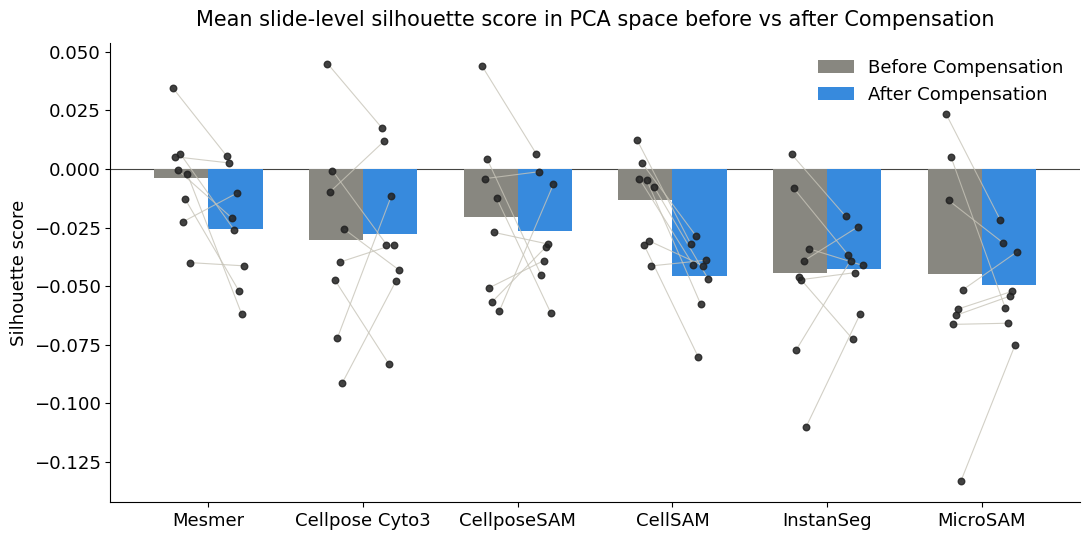

In [11]:
# ============================================================
# PANEL A: SILHOUETTE SCORE
# ============================================================

plot_method_before_after(
    slide_clustering_results,
    "silhouette",
)


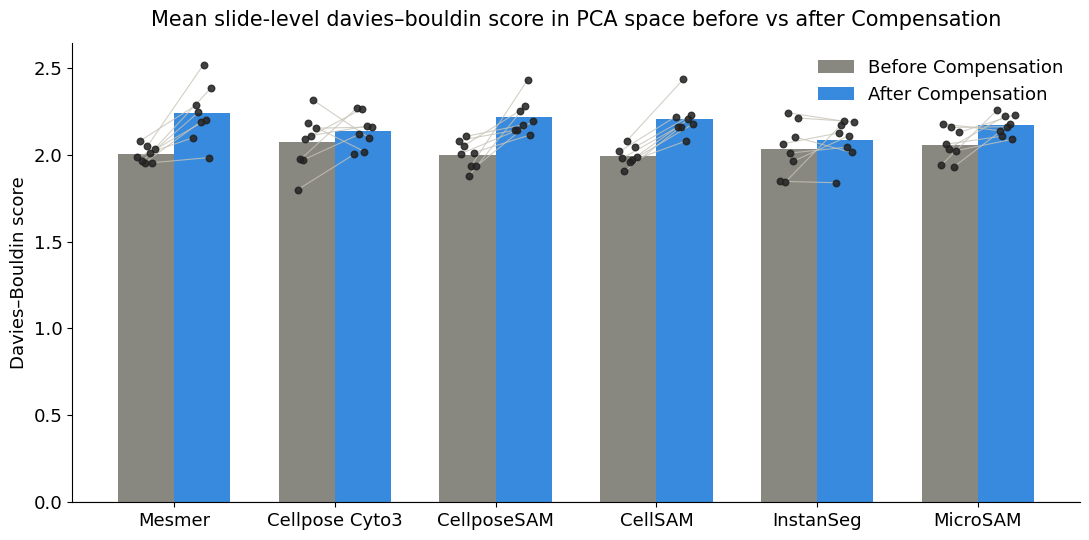

In [12]:
# ============================================================
# PANEL B: DAVIES–BOULDIN SCORE
# ============================================================

plot_method_before_after(
    slide_clustering_results,
    "davies_bouldin",
)


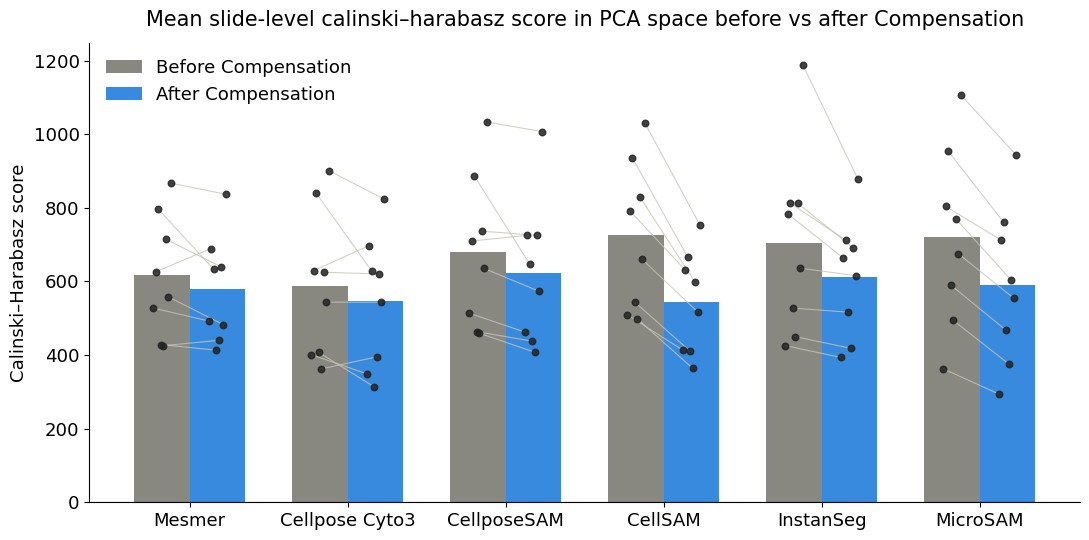

In [13]:
# ============================================================
# PANEL C: CALINSKI–HARABASZ SCORE
# ============================================================

plot_method_before_after(
    slide_clustering_results,
    "calinski_harabasz",
)
